# MOF CO2 Adsorption Prediction (Burner et al. Inspired)


In [2]:
import sys
print(sys.version)

3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


In [3]:
!pip install tensorflow

  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
    --------------------------------------- 6.3/351.2 MB 36.5 MB/s eta 0:00:10
   - -------------------------------------- 14.2/351.2 MB 37.0 MB/s eta 0:00:10
   -- ------------------------------------- 22.5/351.2 MB 37.4 MB/s eta 0:00:09
   --- ------------------------------------ 30.1/351.2 MB 37.3 MB/s eta 0:00:09
   ---- ----------------------------------- 37.7/351.2 MB 37.2 MB/s eta 0:00:09
   ----- ---------------------------------- 45.6/351.2 MB 37.5 MB/s eta 0:00:09
   ------ -------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [4]:
import pandas as pd
import numpy as np
import zipfile
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [5]:
geom = pd.read_csv('CRAFTED_geometric.csv')
rac = pd.read_csv('CoRE2019_full_featurization_frame.csv')
ZIP_FILE='ISOTHERM_FILES.zip'


In [6]:
# Extract CO2 uptake at 100000 Pa from UFF_CO2_298 files
records=[]
with zipfile.ZipFile(ZIP_FILE) as z:
    files=[f for f in z.namelist() if 'UFF_CO2_298' in f and f.endswith('.csv')]
    for f in files:
        try:
            df=pd.read_csv(z.open(f))
            p=df.iloc[:,0]
            y=df.iloc[:,1]
            idx=(p-100000).abs().idxmin()
            mof=Path(f).stem.replace('_UFF_CO2_298','').replace('DDEC_','')
            records.append([mof,float(y.loc[idx])])
        except Exception:
            pass
target_df=pd.DataFrame(records,columns=['FrameworkName','CO2_Uptake'])


In [9]:
print(geom.columns[0])
print(rac.columns[0])

print(geom[geom.columns[0]].dtype)
print(rac[rac.columns[0]].dtype)

FrameworkName
f-chi-0-all
object
float64


In [11]:
print(geom.columns.tolist())

['FrameworkName', 'D_is', 'D_fs', 'D_isfs', 'ASA_m^2/cm^3', 'ASA_m^2/g', 'NASA_m^2/cm^3', 'NASA_m^2/g', 'Unitcell_volume', 'Density', 'AV_Volume_fraction', 'AV_cm^3/g', 'NAV_Volume_fraction', 'NAV_cm^3/g', 'n_pockets']


In [12]:
print(geom.head())

  FrameworkName      D_is      D_fs    D_isfs  ASA_m^2/cm^3  ASA_m^2/g  \
0        MUVHER   5.24679   3.73170   5.14532      1798.490   1841.510   
1        LACJAC   4.56325   3.36486   4.54840       985.713    619.328   
2        ZNGLUD   3.19455   2.66271   3.17912         0.000      0.000   
3        AMUCOB   4.03894   3.31743   4.03894       346.656    217.564   
4  MIL-88C-open  13.75037  10.89185  13.75037      2126.370   4181.320   

   NASA_m^2/cm^3  NASA_m^2/g  Unitcell_volume  Density  AV_Volume_fraction  \
0          0.000       0.000         2142.190  0.97664            0.073285   
1          0.000       0.000         1588.510  1.59158            0.035390   
2        252.196     152.473          845.325  1.65404            0.000000   
3          0.000       0.000         1064.120  1.59335            0.007940   
4          0.000       0.000         5708.150  0.50854            0.495000   

   AV_cm^3/g  NAV_Volume_fraction  NAV_cm^3/g  n_pockets  
0   0.075038              0

In [13]:
print(rac.columns.tolist()[:20])

['f-chi-0-all', 'f-chi-1-all', 'f-chi-2-all', 'f-chi-3-all', 'f-Z-0-all', 'f-Z-1-all', 'f-Z-2-all', 'f-Z-3-all', 'f-I-0-all', 'f-I-1-all', 'f-I-2-all', 'f-I-3-all', 'f-T-0-all', 'f-T-1-all', 'f-T-2-all', 'f-T-3-all', 'f-S-0-all', 'f-S-1-all', 'f-S-2-all', 'f-S-3-all']


In [14]:
print("FrameworkName" in geom.columns)
print("FrameworkName" in rac.columns)

True
False


In [15]:
geom.columns = geom.columns.str.strip()
rac.columns = rac.columns.str.strip()

print("FrameworkName" in geom.columns)
print("FrameworkName" in rac.columns)

True
False


In [16]:
print(rac.shape)

print(rac.index[:5])

print(rac.head())

(10142, 178)
RangeIndex(start=0, stop=5, step=1)
   f-chi-0-all  f-chi-1-all  f-chi-2-all  f-chi-3-all  f-Z-0-all  f-Z-1-all  \
0     216.7340     413.5808     955.7128    1458.0352     2598.0     6408.0   
1     145.4550     245.2560     615.8416     635.2960     2484.0     5668.0   
2     147.7188     267.5904     629.3056     653.4592     2692.0     6060.0   
3     245.0088     405.0944    1605.5168    2109.1328    11522.0    20736.0   
4     436.0880    1016.7072    4112.6432    5075.0936    88488.0   235840.0   

   f-Z-2-all  f-Z-3-all  f-I-0-all  f-I-1-all  ...  D_func-S-0-all  \
0     9508.0    10848.0       26.0       56.0  ...             0.0   
1     6624.0     7136.0       16.0       36.0  ...             0.0   
2     6816.0     7392.0       16.0       36.0  ...             0.0   
3    41472.0    45312.0       26.0       64.0  ...             0.0   
4   271872.0   442072.0       50.0      192.0  ...             0.0   

   D_func-S-1-all  D_func-S-2-all  D_func-S-3-all  D_fu

In [17]:
# Create FrameworkName from filename

rac["FrameworkName"] = (
    rac["filename"]
    .str.replace("_clean.cif", "", regex=False)
)

print(rac[["filename", "FrameworkName"]].head())

           filename FrameworkName
0  ABAVIJ_clean.cif        ABAVIJ
1  ABAYIO_clean.cif        ABAYIO
2  ABAYOU_clean.cif        ABAYOU
3  ABEFUL_clean.cif        ABEFUL
4  ABESUX_clean.cif        ABESUX


In [18]:
common = set(geom["FrameworkName"]) & set(rac["FrameworkName"])

print("Geom:", len(set(geom["FrameworkName"])))
print("RAC :", len(set(rac["FrameworkName"])))
print("Common:", len(common))

Geom: 726
RAC : 10142
Common: 451


In [22]:
print("Common:", len(common))
print(data.shape)

Common: 451
(451, 193)


In [23]:
print(target_df.shape)
target_df.head()

(2904, 2)


,FrameworkName,CO2_Uptake
0,ABUWOJ,7.418665
1,ACOLIP,6.086837
2,ACUBAB,1.340576
3,AFITIT,3.616716
4,AFOQUI,1.933895


In [24]:
data = data.merge(
    target_df,
    on="FrameworkName",
    how="inner"
)

print(data.shape)

(451, 194)


In [25]:
X = data.drop(
    columns=[
        "FrameworkName",
        "filename",
        "CO2_Uptake",
        "0"
    ],
    errors="ignore"
)

X = X.select_dtypes(include=["number"])

y = data["CO2_Uptake"]

print(X.shape)
print(y.shape)

(451, 190)
(451,)


In [26]:
X = X.replace([np.inf, -np.inf], np.nan)

valid_rows = ~X.isna().any(axis=1)

X = X.loc[valid_rows]
y = y.loc[valid_rows]

print(X.shape)
print(y.shape)

(449, 190)
(449,)


In [28]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=2/3,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(314, 190)
(45, 190)
(90, 190)


In [29]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [30]:
model = Sequential([

    Dense(
        1000,
        activation="relu",
        input_shape=(X_train.shape[1],)
    ),

    Dropout(0.20),

    Dense(
        1000,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        700,
        activation="relu"
    ),

    Dense(1)

])

model.compile(
    optimizer=Adam(
        learning_rate=7.5e-4
    ),
    loss="mse",
    metrics=["mae"]
)

model.summary()

C:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1000)           │       191,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 700)            │       700,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           701 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,893,401 (7.22 MB)

 Trainable params: 1,893,401 (7.22 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(
        X_val,
        y_val
    ),
    epochs=300,
    batch_size=32,
    verbose=1
)

Epoch 1/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 7.6042 - mae: 2.1244 - val_loss: 4.2499 - val_mae: 1.4888
Epoch 2/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 3.5362 - mae: 1.3879 - val_loss: 3.2847 - val_mae: 1.3880
Epoch 3/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 2.4150 - mae: 1.1637 - val_loss: 1.9936 - val_mae: 1.0987
Epoch 4/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 1.5032 - mae: 0.9495 - val_loss: 1.2382 - val_mae: 0.8866
Epoch 5/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 1.3838 - mae: 0.8872 - val_loss: 1.6933 - val_mae: 0.9917
Epoch 6/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 1.0594 - mae: 0.7796 - val_loss: 1.6955 - val_mae: 0.9933
Epoch 7/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.9592 - mae: 0.7351 - val_loss: 1.9461 - val_mae: 1.0537
Epoch 8/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 1.0103 - mae: 0.7495 - val_loss: 1.3104 - val_mae: 0.7999
Epoch 9/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - lo

In [32]:
pred = model.predict(
    X_test
).flatten()

print(
    "R2:",
    r2_score(
        y_test,
        pred
    )
)

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        pred
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
R2: 0.5665415566748027
MAE: 0.7229719058119793
RMSE: 1.1895454931276561


In [33]:
!pip install xgboost

In [34]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)

print("R2:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

R2: 0.8491381799746873
MAE: 0.5135540293355815
RMSE: 0.7017735472392673


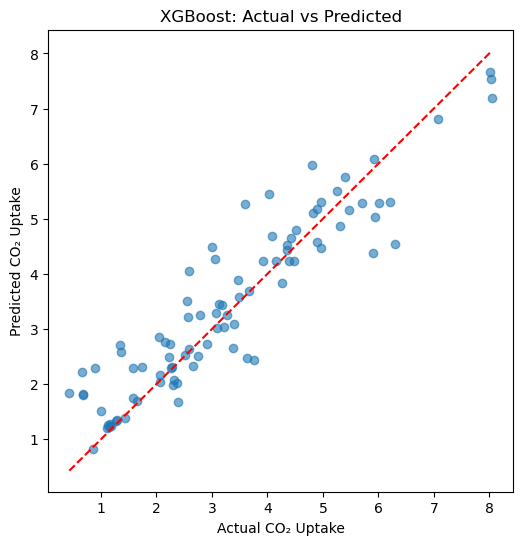

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.6)

mn = min(y_test.min(), pred.min())
mx = max(y_test.max(), pred.max())

plt.plot([mn, mx], [mn, mx], 'r--')

plt.xlabel("Actual CO₂ Uptake")
plt.ylabel("Predicted CO₂ Uptake")
plt.title("XGBoost: Actual vs Predicted")
plt.show()

In [36]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.head(20))

                Feature  Importance
103          lc-I-1-all    0.112642
61         D_mc-Z-3-all    0.090184
50           mc-S-0-all    0.053417
37         mc-chi-3-all    0.045149
38           mc-Z-0-all    0.041654
3          ASA_m^2/cm^3    0.041495
36         mc-chi-2-all    0.025811
34         mc-chi-0-all    0.022045
41           mc-Z-3-all    0.020790
98           lc-Z-0-all    0.020519
4             ASA_m^2/g    0.017728
136        D_lc-S-2-all    0.014288
60         D_mc-Z-2-all    0.014062
187  D_func-alpha-1-all    0.012186
121      D_lc-chi-3-all    0.011859
45           mc-I-3-all    0.010452
148        func-Z-2-all    0.009916
162    func-alpha-0-all    0.009106
171      D_func-Z-1-all    0.008883
73         D_mc-S-3-all    0.008804
